# Expert-guided candidate assessment

This notebook demonstrates an expert-guided approach to evaluating a preselected
redox-active molecule using the OFBO virtual knowledge graph.

Rather than applying fixed screening thresholds, the workflow retrieves available
experimental and computational information associated with one molecule, including
redox potentials, solubility, transport properties, electrochemical reversibility
metrics, computational descriptors, reaction-energy values, experimental conditions,
and provenance.

The returned information is subsequently interpreted by a domain expert in the context
of the intended flow-battery application. This approach is useful when molecular
suitability depends on trade-offs that cannot be fully captured by a single automated
score, such as pH-dependent redox behaviour, degradation pathways, solvent
compatibility, and different redox processes reported in the literature.

For the manuscript case study, this workflow can be applied to Alizarin Red S.

## 1. Imports and Ontop connection

In [ ]:
from pathlib import Path
from io import StringIO
import numpy as np

import pandas as pd
import requests
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


ONTOP_ENDPOINT = "http://localhost:8080/sparql"
TIMEOUT_SECONDS = 120

## 2. SPARQL query

This query retrieves a compact provenance-aware subset of the knowledge graph for
Alizarin Red S (InChIKey: `JKYKXTRKURYNGW-UHFFFAOYSA-N`).

The present visualization is restricted to two experimentally reported property types:

- redox potential; and
- solubility.

For each observation, the query retrieves the numerical value and unit, the potential
reference where applicable, the chemical system used for the measurement, its pH where
available, and the primary literature source. Redox potential is modelled as a property
of an electrochemical reaction, whereas solubility is modelled directly as a property of
the molecular entity. In both cases, the measured property is connected to its generating
experimental process through `prov:wasGeneratedBy` and to the relevant chemical system
through `prov:used`.

The query is intentionally restricted to produce an interpretable local knowledge-graph
view rather than returning all information associated with the molecule. However, the
same query pattern can be extended by adding further OFBO property or reaction classes.
For example, it can retrieve peak-current ratios, peak-potential gaps, diffusion
coefficients, heterogeneous electron-transfer rate constants, calculated redox potentials,
or computational descriptors such as solvation free energies and HOMO–LUMO gaps.

It can also be extended to include degradation-related evidence. For example, bromination
reactions can be retrieved together with their brominated products, reported stability
comments, calculated reaction energies, transition-state energies, computational method,
and literature source. Such extensions enable an expert-guided molecular dossier that
combines electrochemical behaviour, solubility, transport properties, computational
predictions, and stability against specific degradation pathways.

In [2]:
query_file = Path("queries/query_expert_candidate.rq")
query = query_file.read_text(encoding="utf-8")

display(Markdown(f"```sparql\n{query}\n```"))

```sparql
PREFIX ofbo:   <https://w3id.org/ofbo#>
PREFIX schema: <http://schema.org/>
PREFIX sio:    <http://semanticscience.org/resource/>
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX qudt:   <http://qudt.org/schema/qudt/>

SELECT DISTINCT
    ?propertyKind
    ?value
    ?unit
    ?reference
    ?system
    ?composition
    ?pH
    ?source
WHERE {
    {
        # Experimental redox-potential observations
        ?molecule schema:inChIKey "JKYKXTRKURYNGW-UHFFFAOYSA-N" ;
                  ofbo:OFBO_0009206 ?reaction .

        ?property a ofbo:OFBO_0001104 ;
                  sio:SIO_000011 ?reaction ;
                  qudt:numericValue ?value ;
                  qudt:unit ?unit ;
                  ofbo:OFBO_0009202 ?reference ;
                  prov:wasGeneratedBy ?process ;
                  prov:hadPrimarySource ?source .

        ?process a ofbo:OFBO_0008500 ;
                 prov:used ?system .

        ?system schema:chemicalComposition ?composition .

        OPTIONAL {
            ?system sio:SIO_000223 ?pHProperty .
            ?pHProperty a ofbo:OFBO_0001016 ;
                        qudt:numericValue ?pH .
        }

        BIND("Redox potential" AS ?propertyKind)
    }

    UNION

    {
        # Experimental solubility observations
        ?molecule schema:inChIKey "JKYKXTRKURYNGW-UHFFFAOYSA-N" .

        ?property a ofbo:OFBO_0002008 ;
                  sio:SIO_000011 ?molecule ;
                  qudt:numericValue ?value ;
                  qudt:unit ?unit ;
                  prov:wasGeneratedBy ?process ;
                  prov:hadPrimarySource ?source .

        ?process a ofbo:OFBO_0008500 ;
                 prov:used ?system .

        ?system schema:chemicalComposition ?composition .

        OPTIONAL {
            ?system sio:SIO_000223 ?pHProperty .
            ?pHProperty a ofbo:OFBO_0001016 ;
                        qudt:numericValue ?pH .
        }

        BIND("" AS ?reference)
        BIND("Solubility" AS ?propertyKind)
    }
}
ORDER BY ?propertyKind ?value
```

In [3]:
response = requests.post(
    ONTOP_ENDPOINT,
    data={"query": query},
    headers={"Accept": "text/csv"},
    timeout=TIMEOUT_SECONDS,
)

response.raise_for_status()

triples = pd.read_csv(StringIO(response.text)).drop_duplicates()

print(f"Retrieved {len(triples)} triples.")
triples.head()

Retrieved 9 triples.


,propertyKind,value,unit,reference,system,composition,pH,source
0,Redox potential,-0.69182,http://qudt.org/vocab/unit/V,SHE,https://w3id.org/ofbo#SYS_1038srep39101_5_pH13,1 M KOH,13.0,https://doi.org/10.1038/srep39101
1,Redox potential,-0.477,http://qudt.org/vocab/unit/V,NHE,https://w3id.org/ofbo#SYS_jbbabio_199_DMF,"N,N-Dimethylformamide (DMF)",NaN,https://doi.org/10.1016/j.bbabio.2022.148558
2,Redox potential,-0.3471,http://qudt.org/vocab/unit/V,SHE,https://w3id.org/ofbo#SYS_1038srep39101_5_pH7,1 M KCl,7.0,https://doi.org/10.1038/srep39101
3,Redox potential,0.0154,http://qudt.org/vocab/unit/V,SHE,https://w3id.org/ofbo#SYS_1038srep39101_5_pH0,1 M H2SO4,0.0,https://doi.org/10.1038/srep39101
4,Redox potential,0.082,http://qudt.org/vocab/unit/V,SHE,https://w3id.org/ofbo#SYS_201601488_4_HBr,3 M HBr (aq),0.0,https://doi.org/10.1002/aenm.201601488


## 3. Knowledge-graph visualization

The retrieved observations are visualized as a simplified radial knowledge graph.

Alizarin Red S is placed at the centre of the graph. Each reported redox-potential or
solubility observation is shown as a property node connected to the molecule. The
corresponding chemical system and literature source are displayed as outward branches
from each property observation.

Node colours represent semantic categories:

- **orange:** molecule;
- **blue:** reported property observation;
- **yellow:** chemical system and pH condition; and
- **green:** primary literature source.

This reduced graph is designed for interpretability. It does not display every triple
available for Alizarin Red S, such as molecular identifiers, reaction instances,
experimental activities, computational results, or cyclic-voltammetry parameters.
Instead, it highlights the contextual links needed to interpret reported redox potentials
and solubilities across different experimental conditions.

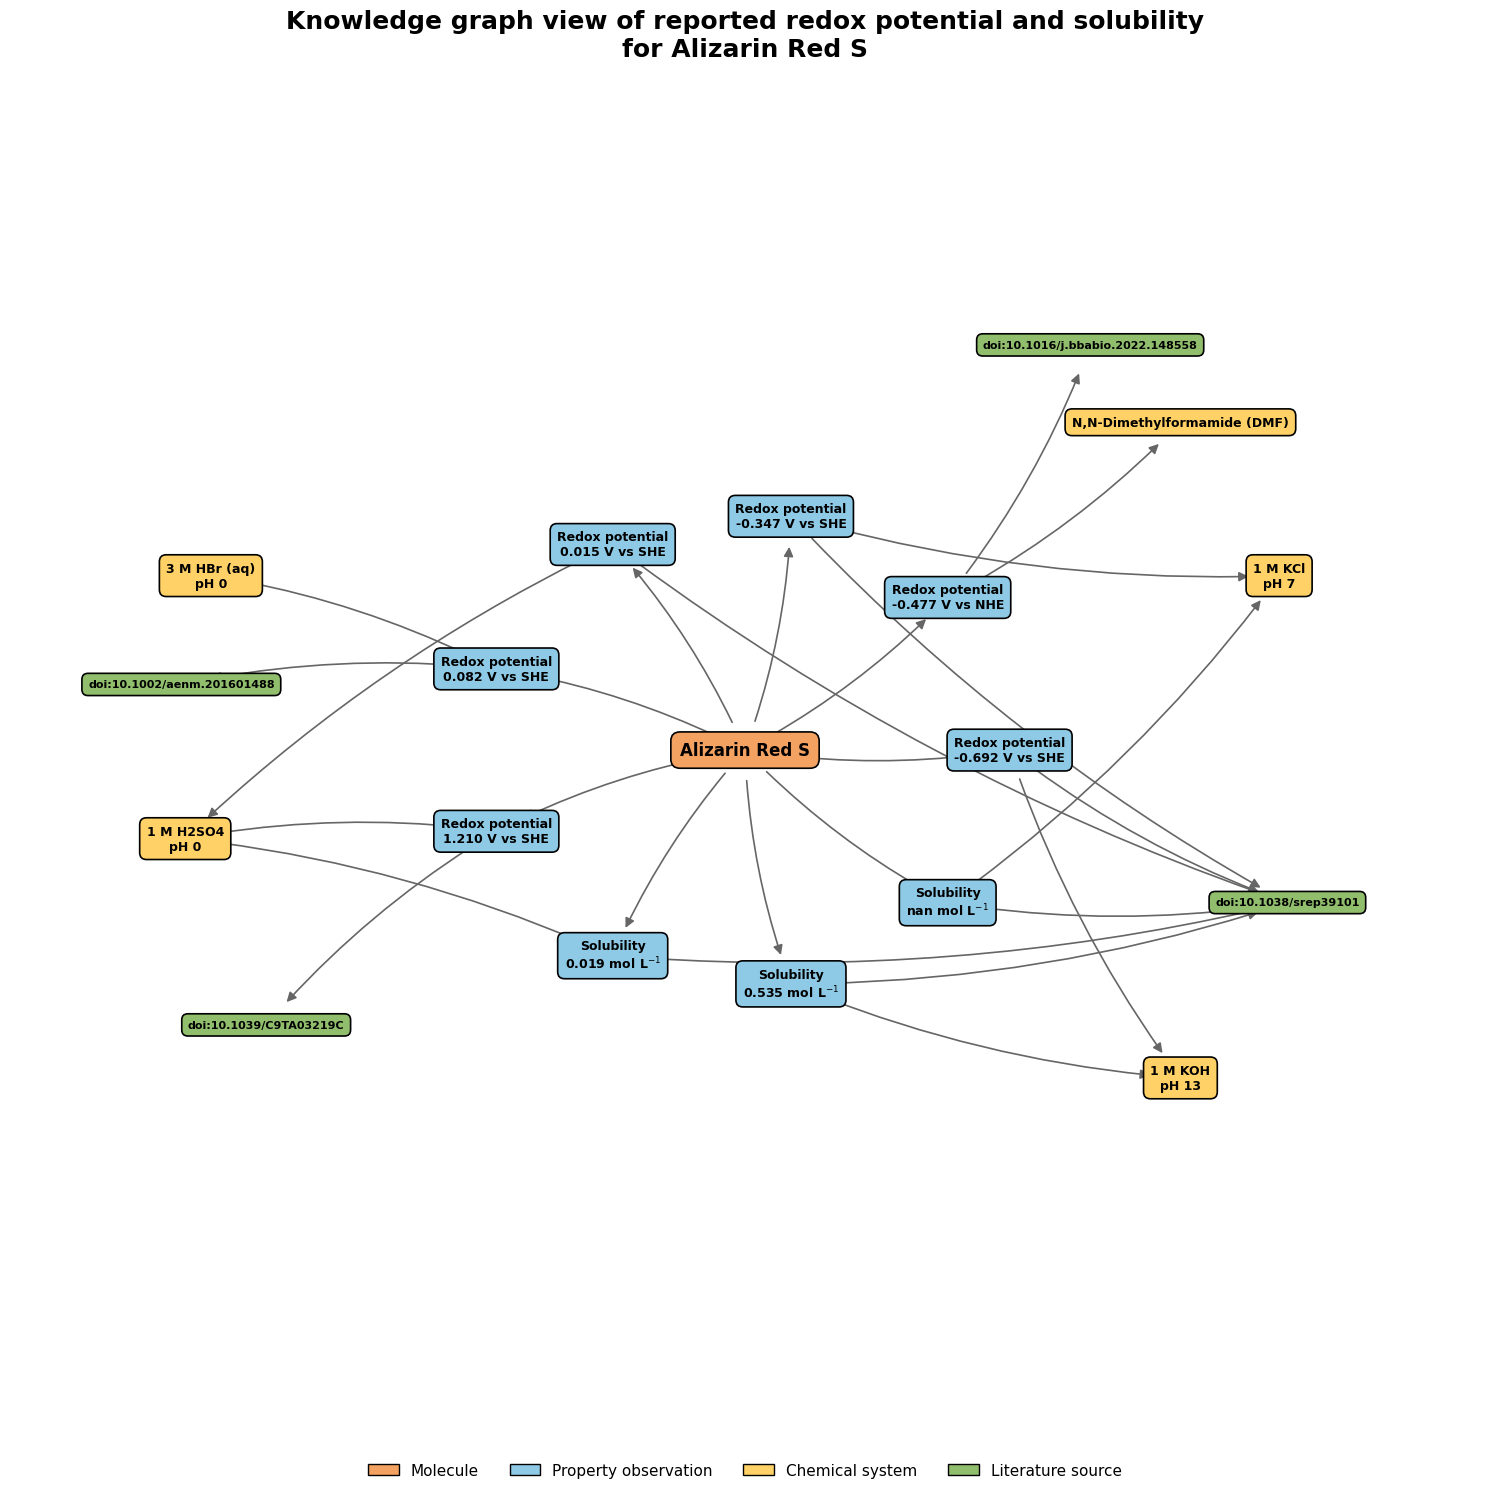

In [4]:
results = triples.copy()

results["value"] = pd.to_numeric(results["value"], errors="coerce")
results["pH"] = pd.to_numeric(results["pH"], errors="coerce")


def short_unit(unit):
    unit = str(unit)

    unit_labels = {
        "http://qudt.org/vocab/unit/V": "V",
        "http://qudt.org/vocab/unit/MOL-PER-L": "mol L$^{-1}$",
        "http://qudt.org/vocab/unit/MOL-PER-M3": "mol m$^{-3}$",
    }

    return unit_labels.get(unit, unit.rsplit("/", 1)[-1])


def short_source(source):
    source = str(source)

    if source.startswith("https://doi.org/"):
        return "doi:" + source.replace("https://doi.org/", "")

    return source


def system_label(row):
    label = str(row["composition"])

    if pd.notna(row["pH"]):
        label += f"\npH {row['pH']:g}"

    return label


# -------------------------------------------------------------------
# Create graph nodes and edges
# -------------------------------------------------------------------

molecule_node = "Alizarin Red S"

property_nodes = []
system_nodes = {}
source_nodes = {}
edges = []

for index, row in results.reset_index(drop=True).iterrows():
    unit = short_unit(row["unit"])
    system = system_label(row)
    source = short_source(row["source"])

    if row["propertyKind"] == "Redox potential":
        property_label = (
            f"Redox potential\n"
            f"{row['value']:.3f} {unit} vs {row['reference']}"
        )
    else:
        property_label = (
            f"Solubility\n"
            f"{row['value']:.3f} {unit}"
        )

    # Unique internal node identifier; label may be shared.
    property_id = f"property_{index}"

    property_nodes.append(
        {
            "id": property_id,
            "label": property_label,
            "angle": None,
        }
    )

    system_nodes.setdefault(
        system,
        {"label": system, "property_ids": []}
    )

    source_nodes.setdefault(
        source,
        {"label": source, "property_ids": []}
    )

    system_nodes[system]["property_ids"].append(property_id)
    source_nodes[source]["property_ids"].append(property_id)

    edges.append((molecule_node, property_id))
    edges.append((property_id, system))
    edges.append((property_id, source))


# -------------------------------------------------------------------
# Radial node positions
# -------------------------------------------------------------------

n_properties = len(property_nodes)

angles = np.linspace(
    0,
    2 * np.pi,
    n_properties,
    endpoint=False,
)

property_positions = {}

for property_data, angle in zip(property_nodes, angles):
    property_data["angle"] = angle

    property_positions[property_data["id"]] = (
        2.7 * np.cos(angle),
        2.7 * np.sin(angle),
    )


def circular_mean(angles):
    """Return the circular mean angle."""
    return np.arctan2(
        np.mean(np.sin(angles)),
        np.mean(np.cos(angles)),
    )


property_angle_lookup = {
    property_data["id"]: property_data["angle"]
    for property_data in property_nodes
}

system_positions = {}

for system, data in system_nodes.items():
    node_angles = [
        property_angle_lookup[property_id]
        for property_id in data["property_ids"]
    ]

    angle = circular_mean(node_angles)

    system_positions[system] = (
        5.8 * np.cos(angle),
        5.8 * np.sin(angle),
    )


source_positions = {}

for source, data in source_nodes.items():
    node_angles = [
        property_angle_lookup[property_id]
        for property_id in data["property_ids"]
    ]

    # Small angular shift separates source and system nodes.
    angle = circular_mean(node_angles) + 0.22

    source_positions[source] = (
        5.8 * np.cos(angle),
        5.8 * np.sin(angle),
    )


positions = {
    molecule_node: (0, 0),
    **property_positions,
    **system_positions,
    **source_positions,
}


# -------------------------------------------------------------------
# Draw helpers
# -------------------------------------------------------------------

colours = {
    "molecule": "#f4a261",
    "property": "#8ecae6",
    "system": "#ffd166",
    "source": "#90be6d",
}


def draw_box(ax, x, y, label, colour, fontsize=9):
    ax.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor=colour,
            edgecolor="black",
            linewidth=1.2,
        ),
        zorder=3,
    )


def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.2,
        color="#666666",
        shrinkA=22,
        shrinkB=22,
        connectionstyle="arc3,rad=0.08",
        zorder=1,
    )

    ax.add_patch(arrow)


# -------------------------------------------------------------------
# Plot radial knowledge graph
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 15))

# Draw edges.
for source, target in edges:
    draw_arrow(ax, positions[source], positions[target])

# Centre molecule.
draw_box(
    ax,
    0,
    0,
    molecule_node,
    colours["molecule"],
    fontsize=12,
)

# Property nodes.
for property_data in property_nodes:
    x, y = positions[property_data["id"]]

    draw_box(
        ax,
        x,
        y,
        property_data["label"],
        colours["property"],
        fontsize=9,
    )

# Chemical-system nodes.
for system, data in system_nodes.items():
    x, y = system_positions[system]

    draw_box(
        ax,
        x,
        y,
        data["label"],
        colours["system"],
        fontsize=9,
    )

# Literature-source nodes.
for source, data in source_nodes.items():
    x, y = source_positions[source]

    draw_box(
        ax,
        x,
        y,
        data["label"],
        colours["source"],
        fontsize=8,
    )

# Legend.
legend_items = [
    FancyBboxPatch((0, 0), 1, 1, facecolor=colours["molecule"], edgecolor="black"),
    FancyBboxPatch((0, 0), 1, 1, facecolor=colours["property"], edgecolor="black"),
    FancyBboxPatch((0, 0), 1, 1, facecolor=colours["system"], edgecolor="black"),
    FancyBboxPatch((0, 0), 1, 1, facecolor=colours["source"], edgecolor="black"),
]

ax.legend(
    legend_items,
    ["Molecule", "Property observation", "Chemical system", "Literature source"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=4,
    frameon=False,
    fontsize=11,
)

ax.set_title(
    "Knowledge graph view of reported redox potential and solubility\n"
    "for Alizarin Red S",
    fontsize=18,
    fontweight="bold",
    pad=25,
)

ax.set_xlim(-7.5, 7.5)
ax.set_ylim(-7.5, 7.5)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    "alizarin_red_s_radial_knowledge_graph.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()